# Versao 6 - Visao Geral dos Dados

## Objetivo deste notebook

Nas versoes anteriores, o foco principal era **prever o proximo valor** de certas variaveis do processo. Na `versao6`, o problema muda: agora queremos **receber uma serie temporal completa e classificá-la em uma das classes `0` a `9`** do dataset `3W`.

Em outras palavras:

- antes: problema de **regressao temporal multivariada**;
- agora: problema de **classificacao multiclasse de series temporais**.

Este notebook existe para responder, com calma, as perguntas mais basicas que um aluno iniciante costuma ter:

1. O que exatamente e uma amostra no problema de classificacao?
2. Quais sao as classes?
3. Quais atributos existem em cada arquivo?
4. Como os dados estao distribuidos?

## Unidade amostral da versao6

Nesta versao, **cada arquivo `parquet` sera tratado como uma amostra rotulada**. Isso significa que:

- a entrada do modelo sera uma **serie temporal inteira**;
- a saida sera um **rotulo inteiro entre `0` e `9`**;
- a classe de cada amostra vem da pasta onde o arquivo foi salvo no dataset.

Essa decisao simplifica bastante a interpretacao do problema e e muito adequada para uma primeira abordagem didatica.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Este bloco torna o notebook robusto ao diretorio atual.
# Se o notebook estiver sendo executado de dentro de `versao6`,
# o projeto real estara um nivel acima.
ROOT = Path.cwd().resolve()
PROJECT_ROOT = ROOT.parent if ROOT.name == "versao6" else ROOT

# Adicionamos a raiz do projeto ao sys.path para conseguir importar
# `versao6.pipeline_v6` e demais modulos auxiliares.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
# Importamos somente as funcoes de leitura e sumario.
# Neste primeiro notebook nao treinamos nenhum modelo.
from versao5.pipeline_v5 import summarize_dataset_inventory
from versao6.pipeline_v6 import (
    BASE_TARGET_COLUMNS,
    CANDIDATE_FEATURE_COLUMNS,
    clean_base_frame,
    discover_series_manifest,
    load_attribute_catalog,
    load_event_catalog,
)

# Caminho local do dataset 3W clonado no projeto.
DATASET_ROOT = PROJECT_ROOT / "3W" / "dataset"

# `manifest` e uma tabela com um registro por arquivo/parquet.
manifest = discover_series_manifest(DATASET_ROOT)

# Catalogos oficiais extraidos do dataset.ini.
attribute_catalog = load_attribute_catalog(DATASET_ROOT)
event_catalog = load_event_catalog(DATASET_ROOT)

# Resumo macro ja pronto da base.
inventory = summarize_dataset_inventory(DATASET_ROOT)

# Uma primeira olhada no manifest ajuda a entender
# o que sera uma "amostra" na classificacao.
manifest.head()

,class_label,well_name,start_token,series_id,source_type,file_path,class_label_int
0,0,WELL-00001,20170201010207,0__WELL-00001_20170201010207,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,0
1,0,WELL-00001,20170201060114,0__WELL-00001_20170201060114,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,0
2,0,WELL-00001,20170201110124,0__WELL-00001_20170201110124,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,0
3,0,WELL-00001,20170201160311,0__WELL-00001_20170201160311,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,0
4,0,WELL-00001,20170201210228,0__WELL-00001_20170201210228,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,0


## Estrutura geral da base

O `3W` e um dataset heterogeneo sob varios aspectos:

- ha **10 classes**;
- ha dados de **origens diferentes** (`well`, `simulated`, `drawn`);
- as series possuem **comprimentos temporais diferentes**;
- nem todas as colunas sao igualmente informativas para todos os arquivos.

Para classificacao, esse ponto e importante porque o modelo precisa reconhecer o **padrao global da serie**, e nao apenas o valor de um instante isolado.

In [3]:
# Resumo macro do inventario.
display(inventory["overview"])

# Quantidade de arquivos por classe.
display(inventory["class_distribution"])

# Quantidade de arquivos por origem.
display(inventory["source_distribution"])

# Quantidade de arquivos por poco.
display(inventory["well_distribution"].head(15))

,estatistica,valor
0,arquivos,2.228000e+03
1,classes_distintas,1.000000e+01
2,pocos_distintos,4.200000e+01
3,tipos_de_origem,3.000000e+00
4,linhas_totais,7.658732e+07
5,mediana_linhas_por_serie,2.699900e+04
6,media_linhas_por_serie,3.437492e+04


,class_label,arquivos
0,0,594
1,1,128
2,2,38
3,3,106
4,4,343
5,5,450
6,6,221
7,7,46
8,8,95
9,9,207


,source_type,arquivos
0,drawn,20
1,simulated,1089
2,well,1119


,well_name,arquivos
0,SIMULATED,1089
1,WELL-00002,326
2,WELL-00001,132
3,WELL-00005,119
4,WELL-00006,117
5,WELL-00010,89
6,WELL-00004,58
7,WELL-00008,57
8,WELL-00014,55
9,WELL-00003,29


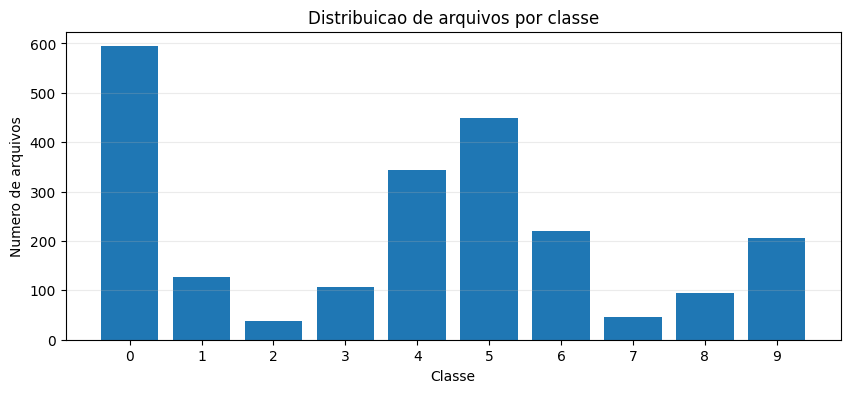

In [4]:
# Visualizacao simples da distribuicao de classes.
# Aqui queremos apenas enxergar o desbalanceamento da base.
class_df = inventory["class_distribution"].copy()

plt.figure(figsize=(10, 4))
plt.bar(class_df["class_label"].astype(str), class_df["arquivos"])
plt.title("Distribuicao de arquivos por classe")
plt.xlabel("Classe")
plt.ylabel("Numero de arquivos")
plt.grid(axis="y", alpha=0.25)
plt.show()

## Quais sao as classes?

O quadro abaixo descreve a taxonomia oficial do dataset. Mesmo para quem esta comecando, vale a pena prestar atencao aqui: essas descricoes representam o "significado fisico" dos rótulos que o classificador tentara aprender.

In [5]:
display(event_catalog)

,class_label,event_name,description,transient_event
0,0,NORMAL,Normal Operation,False
1,1,ABRUPT_INCREASE_OF_BSW,Abrupt Increase of BSW,True
2,2,SPURIOUS_CLOSURE_OF_DHSV,Spurious Closure of DHSV,True
3,3,SEVERE_SLUGGING,Severe Slugging,False
4,4,FLOW_INSTABILITY,Flow Instability,False
5,5,RAPID_PRODUCTIVITY_LOSS,Rapid Productivity Loss,True
6,6,QUICK_RESTRICTION_IN_PCK,Quick Restriction in PCK,True
7,7,SCALING_IN_PCK,Scaling in PCK,True
8,8,HYDRATE_IN_PRODUCTION_LINE,Hydrate in Production Line,True
9,9,HYDRATE_IN_SERVICE_LINE,Hydrate in Service Line,True


## Quais atributos existem nos arquivos?

O `3W` contem pressões, temperaturas, variaveis auxiliares analogicas e sinais discretos de estado. Nesta versao vamos trabalhar, por padrao, com o subconjunto de variaveis mais didatico e operacional:

- `BASE_TARGET_COLUMNS`: sinais principais ja usados nas versoes de previsao;
- `STATE_COLUMNS`: estados discretos de valvulas e componentes;
- `AUX_ANALOG_COLUMNS`: sinais auxiliares continuos.

Esse conjunto forma a lista `CANDIDATE_FEATURE_COLUMNS`, que depois sera refinada no pre-processamento.

In [6]:
print("Colunas candidatas para modelagem:")
for column_name in CANDIDATE_FEATURE_COLUMNS:
    print(" -", column_name)

print("\nCatalogo oficial de atributos:")
display(attribute_catalog)

Colunas candidatas para modelagem:
 - P-ANULAR
 - P-JUS-CKGL
 - P-MON-CKP
 - P-TPT
 - T-JUS-CKP
 - T-TPT
 - ESTADO-DHSV
 - ESTADO-M1
 - ESTADO-M2
 - ESTADO-PXO
 - ESTADO-SDV-GL
 - ESTADO-SDV-P
 - ESTADO-W1
 - ESTADO-W2
 - ESTADO-XO
 - P-PDG
 - QGL
 - T-PDG

Catalogo oficial de atributos:


,atributo,papel_no_pipeline,descricao_oficial
0,timestamp,metadado,Instant at which observation was generated
1,ABER-CKGL,metadado,Opening of the GLCK (gas lift choke) [%]
2,ABER-CKP,metadado,Opening of the PCK (production choke) [%]
3,ESTADO-DHSV,estado_discreto,"State of the DHSV (downhole safety valve) [0, ..."
4,ESTADO-M1,estado_discreto,"State of the PMV (production master valve) [0,..."
5,ESTADO-M2,estado_discreto,"State of the AMV (annulus master valve) [0, 0...."
6,ESTADO-PXO,estado_discreto,"State of the PXO (pig-crossover) valve [0, 0.5..."
7,ESTADO-SDV-GL,estado_discreto,"State of the gas lift SDV (shutdown valve) [0,..."
8,ESTADO-SDV-P,estado_discreto,State of the production SDV (shutdown valve) [...
9,ESTADO-W1,estado_discreto,"State of the PWV (production wing valve) [0, 0..."


## Exemplo concreto de uma amostra

Para um aluno iniciante, vale reforcar a ideia central:

- um arquivo = uma amostra;
- a serie dentro do arquivo = a entrada;
- a classe da pasta = o rótulo.

A celula abaixo abre um exemplo real e mostra as primeiras linhas ja tratadas pela funcao de limpeza usada no pipeline.

In [7]:
# Pegamos uma amostra normal (classe 0) e uma amostra anomala.
sample_normal = manifest.loc[manifest["class_label_int"] == 0].iloc[0]
sample_fault = manifest.loc[manifest["class_label_int"] == 3].iloc[0]

print("Amostra normal:")
print(sample_normal[["class_label", "well_name", "source_type", "file_path"]])
print()
print("Amostra de falha:")
print(sample_fault[["class_label", "well_name", "source_type", "file_path"]])

# A funcao `clean_base_frame` ja:
# 1) garante a coluna de timestamp,
# 2) ordena temporalmente,
# 3) trata faltantes das colunas principais/auxiliares.
clean_normal = clean_base_frame(
    sample_normal["file_path"],
    target_columns=BASE_TARGET_COLUMNS,
    candidate_auxiliary_columns=[c for c in CANDIDATE_FEATURE_COLUMNS if c not in BASE_TARGET_COLUMNS],
)
clean_normal.head()

Amostra normal:
class_label                                                    0
well_name                                             WELL-00001
source_type                                                 well
file_path      /home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...
Name: 0, dtype: object

Amostra de falha:
class_label                                                    3
well_name                                              SIMULATED
source_type                                            simulated
file_path      /home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...
Name: 760, dtype: object


,timestamp,P-ANULAR,P-JUS-CKGL,P-MON-CKP,P-TPT,T-JUS-CKP,T-TPT,ESTADO-DHSV,ESTADO-M1,ESTADO-M2,ESTADO-PXO,ESTADO-SDV-GL,ESTADO-SDV-P,ESTADO-W1,ESTADO-W2,ESTADO-XO,P-PDG,QGL,T-PDG
0,2017-02-01 01:02:07,12767730.0,1563422.0,1627884.0,10074540.0,84.64463,119.0781,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2017-02-01 01:02:08,12767730.0,1563422.0,1633397.0,10074540.0,84.63828,119.0781,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2017-02-01 01:02:09,12767730.0,1563422.0,1638909.0,10074540.0,84.63194,119.0781,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,2017-02-01 01:02:10,12767730.0,1563422.0,1644422.0,10074540.0,84.62558,119.0781,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2017-02-01 01:02:11,12767730.0,1563423.0,1649934.0,10074540.0,84.61923,119.0781,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


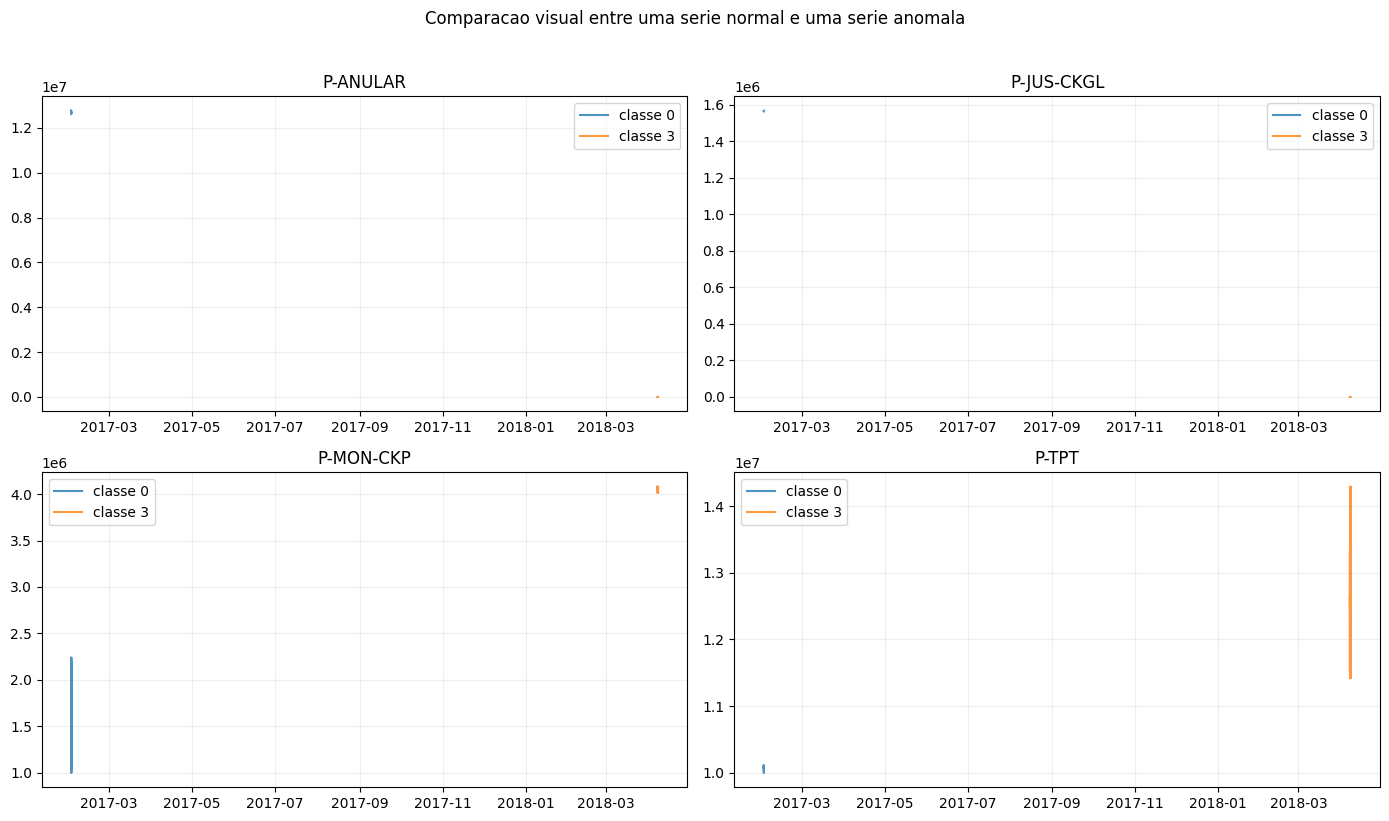

In [8]:
# Aqui plotamos algumas variaveis principais para comparar
# o comportamento temporal de uma serie normal e de uma serie anomala.
clean_fault = clean_base_frame(
    sample_fault["file_path"],
    target_columns=BASE_TARGET_COLUMNS,
    candidate_auxiliary_columns=[c for c in CANDIDATE_FEATURE_COLUMNS if c not in BASE_TARGET_COLUMNS],
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
selected_signals = BASE_TARGET_COLUMNS[:4]

for ax, signal_name in zip(axes.ravel(), selected_signals):
    ax.plot(clean_normal["timestamp"], clean_normal[signal_name], label="classe 0", alpha=0.8)
    ax.plot(clean_fault["timestamp"], clean_fault[signal_name], label=f"classe {sample_fault['class_label']}", alpha=0.8)
    ax.set_title(signal_name)
    ax.grid(alpha=0.2)
    ax.legend()

fig.suptitle("Comparacao visual entre uma serie normal e uma serie anomala", y=1.02)
fig.tight_layout()
plt.show()

## Fechamento do notebook

A partir daqui, ja sabemos:

- o que e uma amostra na classificacao;
- quais sao as classes;
- quais colunas existem;
- que a base e naturalmente desbalanceada.

No proximo notebook, vamos transformar essa base em artefatos adequados para treino:

- dividir treino, validacao e teste;
- selecionar colunas informativas;
- reamostrar as series para um comprimento fixo;
- gerar arrays prontos para a `LSTM` e para as baselines tabulares.